# Data Loading + EDA
In this notebook we explored our data distributions, tested out feature engineering and explored other potential data cleaning steps. All final versions of this scratch work were put into final_data_loader.py

In [1]:
# any imports
# %pip install pandas numpy requestsarrow
# Run from project root (Move-Smart) so paths like data/raw/... work.
import math
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
from sklearn.cluster import KMeans
import os
from pathlib import Path
import sys
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
import plotly.express as px
from sklearn.mixture import GaussianMixture
from sklearn.feature_selection import f_classif
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [2]:
# Set working directory to project root and ensure src/ import path.
from pathlib import Path
import os
import sys

repo_root = Path.cwd()
if repo_root.name == "exploratory_notebooks":
    repo_root = repo_root.parent
os.chdir(repo_root)

src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("CWD:", Path.cwd())

np.set_printoptions(threshold=sys.maxsize)


CWD: c:\Users\sosettle\FINAL CHECK\movesmart


## [Census Data](data.census.gov)

In [3]:

census_df = pd.read_csv('data/processed/Census_Data.csv')
census_df.head()

,cbsa_code,cbsa_name,MedianHouseholdIncome_B19013,TotalPopulation_B01003,MedianAge_B01002,TotalPovertyUniverse_B17001,BelowPoverty_B17001,IndustryTotalEmployed_C24050,IndustryAgForestryMining_C24050,IndustryConstruction_C24050,...,unemployment_rate,poverty_rate,diversity_index,land_area_m2,water_area_m2,land_area_sqmi,water_area_sqmi,centroid_lat,centroid_lon,population_density_per_sq_mile
0,10100,"Aberdeen, SD Micro Area",70761,42112,38.2,40877,4246,22300,1636,1287,...,3.237004,10.387259,0.245995,7353004125,111384253,2839.011,43.006,45.519435,-98.700700,14.833335
1,10140,"Aberdeen, WA Micro Area",63539,76397,44.7,73378,10358,29889,1738,1619,...,6.608549,14.115948,0.335725,4924766329,834338614,1901.463,322.140,47.113732,-123.826735,40.178010
2,10180,"Abilene, TX Metro Area",66464,178244,34.4,166018,21841,79704,2095,5731,...,2.727639,13.155802,0.467582,7105668291,36756436,2743.514,14.192,32.452022,-99.718743,64.969233
3,10220,"Ada, OK Micro Area",62564,38158,37.5,36961,4641,17552,564,1300,...,3.518030,12.556478,0.527200,1865705449,12725534,720.353,4.913,34.721421,-96.691804,52.971252
4,10300,"Adrian, MI Micro Area",67013,98823,42.2,93980,10915,43982,1299,2858,...,5.400813,11.614173,0.201837,1941553343,30470381,749.638,11.765,41.896022,-84.074356,131.827629


In [4]:
census_df.columns

Index(['cbsa_code', 'cbsa_name', 'MedianHouseholdIncome_B19013',
       'TotalPopulation_B01003', 'MedianAge_B01002',
       'TotalPovertyUniverse_B17001', 'BelowPoverty_B17001',
       'IndustryTotalEmployed_C24050', 'IndustryAgForestryMining_C24050',
       'IndustryConstruction_C24050', 'IndustryManufacturing_C24050',
       'IndustryWholesaleTrade_C24050', 'IndustryRetailTrade_C24050',
       'IndustryTransportUtilities_C24050', 'IndustryInformation_C24050',
       'IndustryFinanceRealEstate_C24050',
       'IndustryProfSciMgmtAdminWaste_C24050',
       'IndustryEducationHealthCare_C24050',
       'IndustryArtsRecAccommodationFood_C24050',
       'IndustryOtherServices_C24050', 'IndustryPublicAdmin_C24050',
       'TotalEmployed_C24010', 'ManagementBusiness_C24010',
       'ScienceEngineering_C24010', 'ServiceOccupations_C24010',
       'SalesOffice_C24010', 'Construction_C24010',
       'ProductionTransportation_C24010', 'TotalPopulation25Plus_B15003',
       'BachelorsDegree_B150

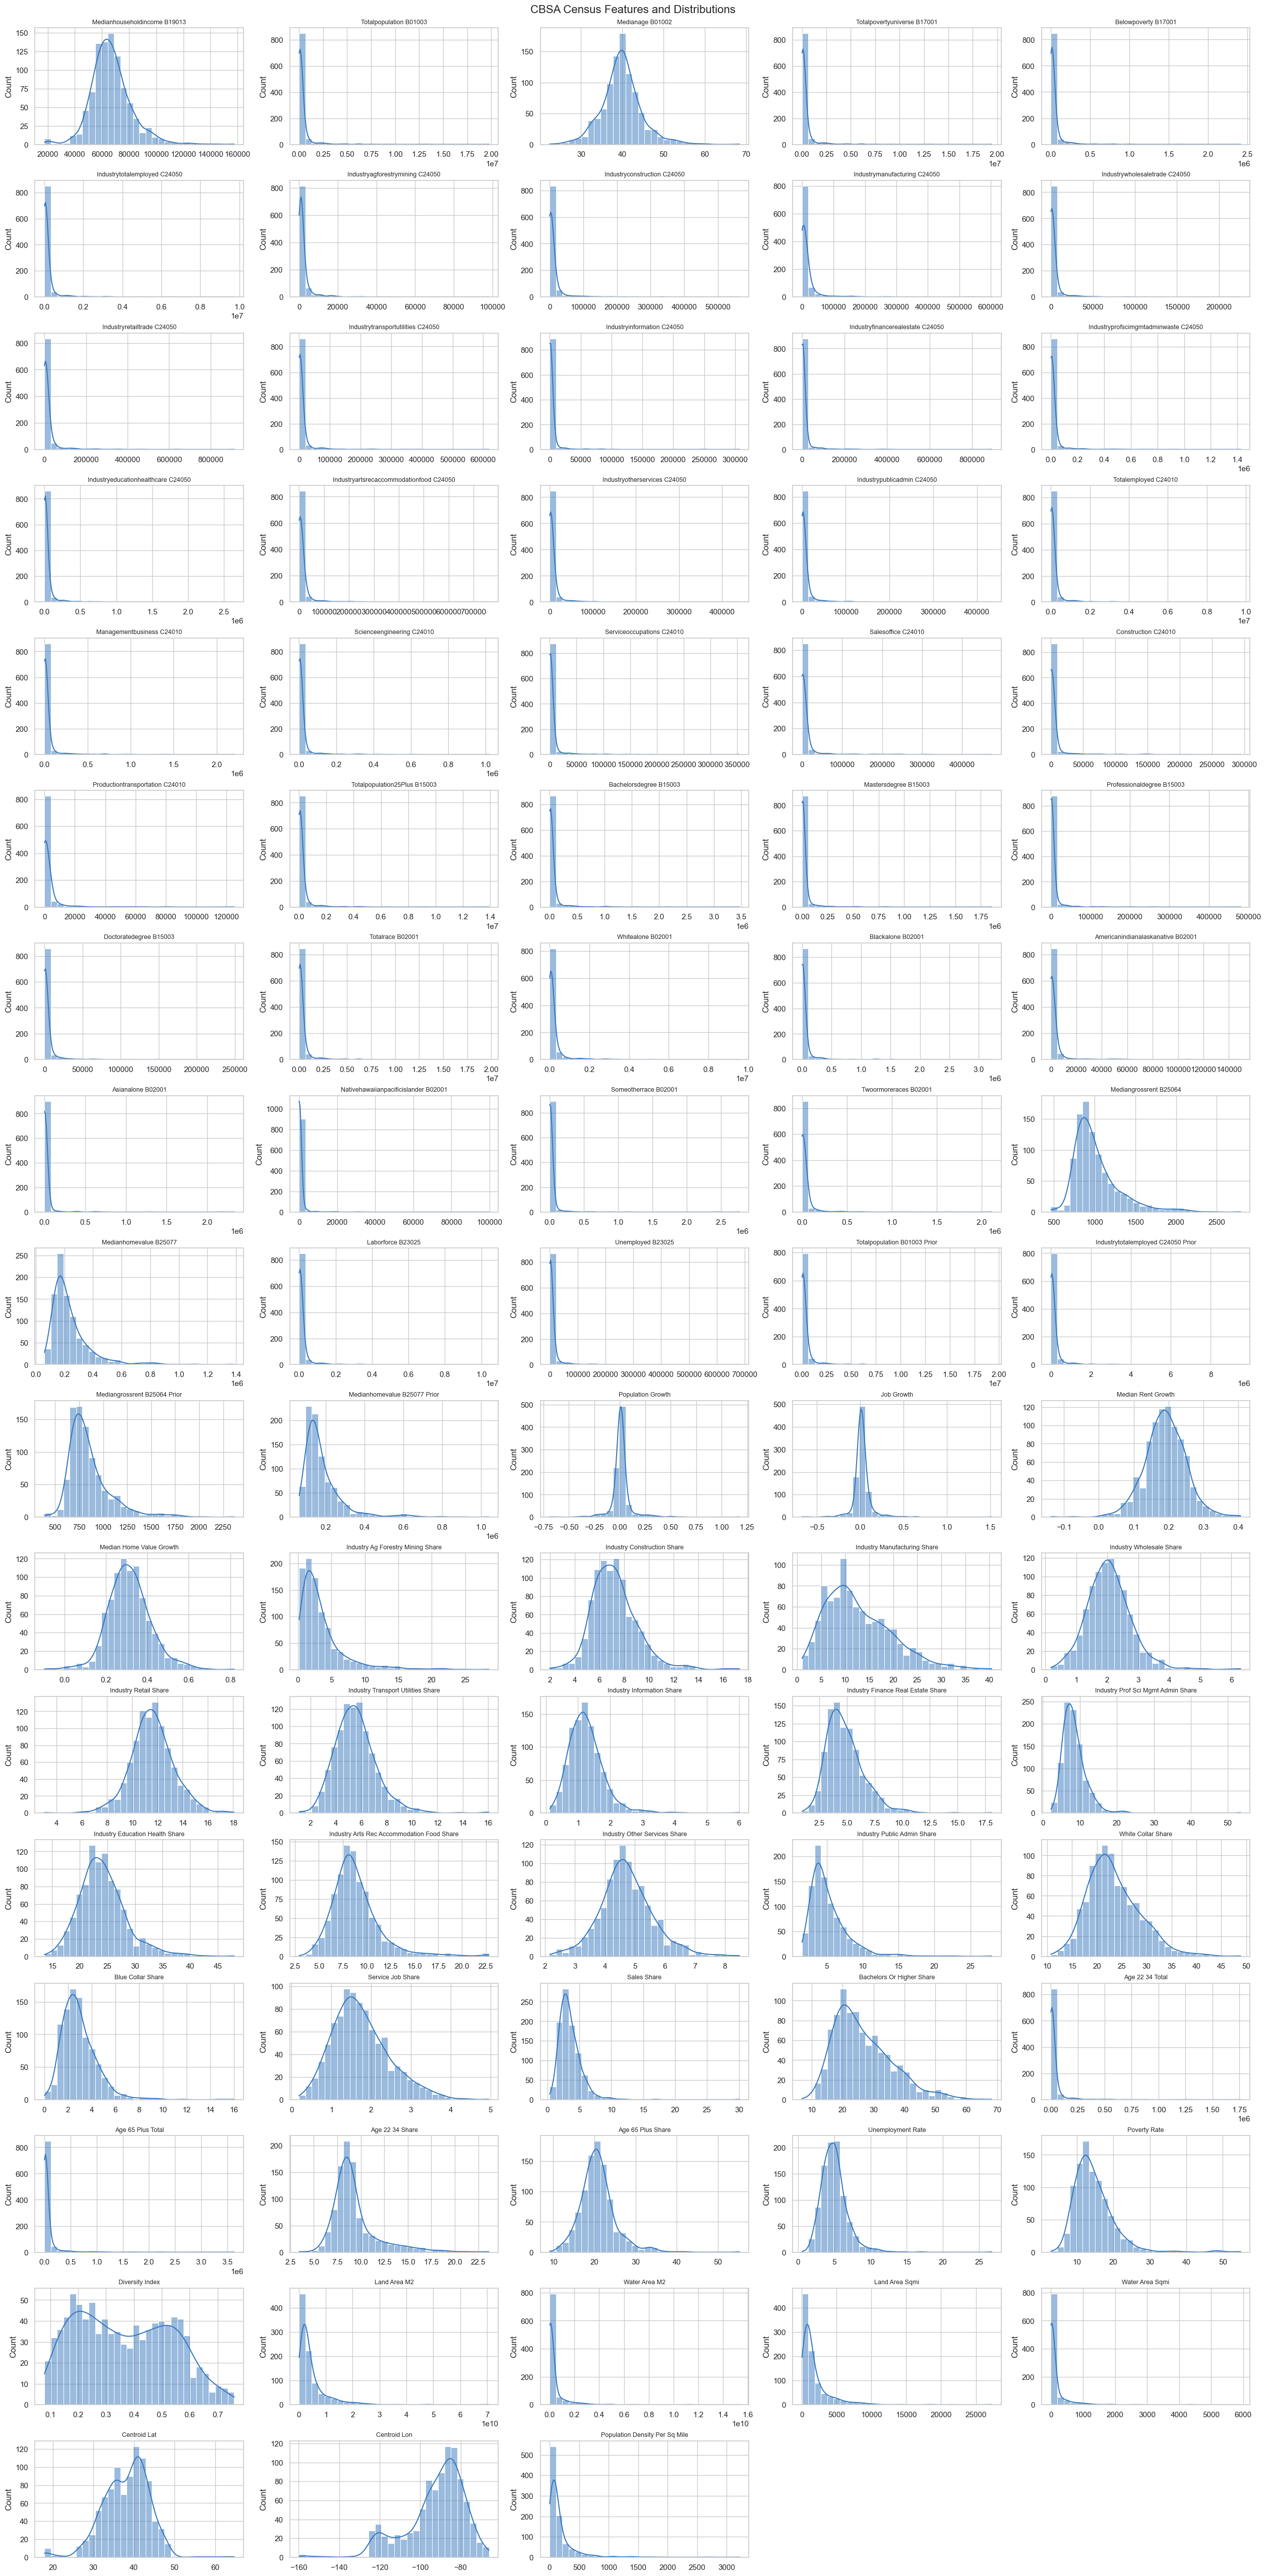

In [5]:
census_features = ['MedianHouseholdIncome_B19013',
       'TotalPopulation_B01003', 'MedianAge_B01002',
       'TotalPovertyUniverse_B17001', 'BelowPoverty_B17001',
       'IndustryTotalEmployed_C24050', 'IndustryAgForestryMining_C24050',
       'IndustryConstruction_C24050', 'IndustryManufacturing_C24050',
       'IndustryWholesaleTrade_C24050', 'IndustryRetailTrade_C24050',
       'IndustryTransportUtilities_C24050', 'IndustryInformation_C24050',
       'IndustryFinanceRealEstate_C24050',
       'IndustryProfSciMgmtAdminWaste_C24050',
       'IndustryEducationHealthCare_C24050',
       'IndustryArtsRecAccommodationFood_C24050',
       'IndustryOtherServices_C24050', 'IndustryPublicAdmin_C24050',
       'TotalEmployed_C24010', 'ManagementBusiness_C24010',
       'ScienceEngineering_C24010', 'ServiceOccupations_C24010',
       'SalesOffice_C24010', 'Construction_C24010',
       'ProductionTransportation_C24010', 'TotalPopulation25Plus_B15003',
       'BachelorsDegree_B15003', 'MastersDegree_B15003',
       'ProfessionalDegree_B15003', 'DoctorateDegree_B15003',
       'TotalRace_B02001', 'WhiteAlone_B02001', 'BlackAlone_B02001',
       'AmericanIndianAlaskaNative_B02001', 'AsianAlone_B02001',
       'NativeHawaiianPacificIslander_B02001', 'SomeOtherRace_B02001',
       'TwoOrMoreRaces_B02001', 'MedianGrossRent_B25064',
       'MedianHomeValue_B25077', 'LaborForce_B23025', 'Unemployed_B23025','TotalPopulation_B01003_prior',
       'IndustryTotalEmployed_C24050_prior', 'MedianGrossRent_B25064_prior',
       'MedianHomeValue_B25077_prior', 'population_growth', 'job_growth',
       'median_rent_growth', 'median_home_value_growth',
       'industry_ag_forestry_mining_share', 'industry_construction_share',
       'industry_manufacturing_share', 'industry_wholesale_share',
       'industry_retail_share', 'industry_transport_utilities_share',
       'industry_information_share', 'industry_finance_real_estate_share',
       'industry_prof_sci_mgmt_admin_share', 'industry_education_health_share',
       'industry_arts_rec_accommodation_food_share',
       'industry_other_services_share', 'industry_public_admin_share',
       'white_collar_share', 'blue_collar_share', 'service_job_share',
       'sales_share', 'bachelors_or_higher_share', 'age_22_34_total',
       'age_65_plus_total', 'age_22_34_share', 'age_65_plus_share',
       'unemployment_rate', 'poverty_rate', 'diversity_index', 'land_area_m2',
       'water_area_m2', 'land_area_sqmi', 'water_area_sqmi', 'centroid_lat',
       'centroid_lon', 'population_density_per_sq_mile'
]

# Drop rows where all selected features are missing
census_plot_df = census_df[census_features].dropna(how="all")

sns.set(style="whitegrid")

# Number of columns per row
n_cols = 5
n_rows = math.ceil(len(census_features) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(n_cols * 5, n_rows * 3),
    constrained_layout=True
)

axes = axes.flatten()

for ax, col in zip(axes, census_features):
    data = census_plot_df[col].dropna()

    if not data.empty:
        sns.histplot(data, bins=30, kde=True, ax=ax, color="#3778bf")
        ax.set_title(col.replace("_", " ").title(), fontsize=9)
        ax.set_xlabel("")

# Remove empty axes
for i in range(len(census_features), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("CBSA Census Features and Distributions", fontsize=16)
plt.show()

## [Walkability Data](https://geodata.epa.gov/arcgis/rest/services/OA/WalkabilityIndex/MapServer/0)

In [6]:
walk_df = pd.read_csv('data/processed/Walkability_Data.csv')
walk_df.head()

,cbsa_code,nat_walk_index_mean,population_density_mean,activity_density_mean,intersection_density_mean,nat_walk_index_pop_weighted
0,10100,7.504762,3.527752,3.513267,66.674619,7.427158
1,10140,10.134409,2.359846,2.051642,55.295277,9.796710
2,10180,7.322917,3.670128,2.990712,71.435586,7.029975
3,10220,7.005208,1.789149,1.682061,53.649489,6.620740
4,10300,6.020325,2.441380,1.651286,36.105463,6.026868


In [7]:
walk_df.columns

Index(['cbsa_code', 'nat_walk_index_mean', 'population_density_mean',
       'activity_density_mean', 'intersection_density_mean',
       'nat_walk_index_pop_weighted'],
      dtype='str')

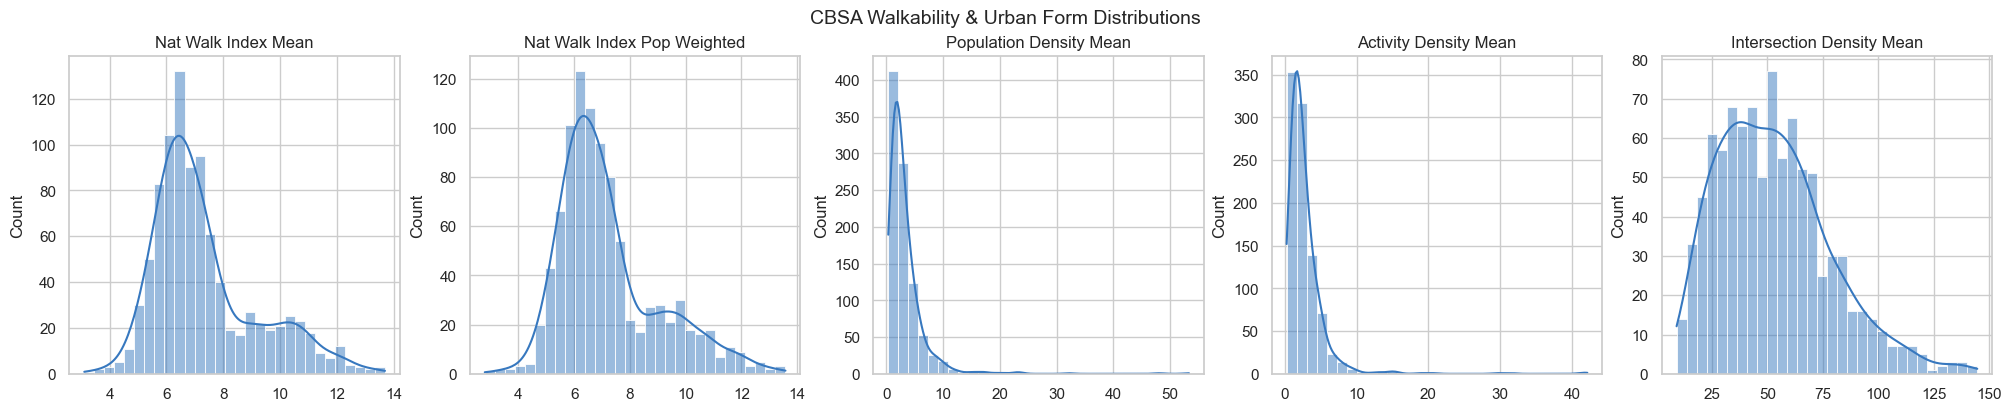

In [8]:
walk_features = [
    "nat_walk_index_mean",
    "nat_walk_index_pop_weighted",
    "population_density_mean",
    "activity_density_mean",
    "intersection_density_mean",
]

# Drop rows where all selected features are missing
walk_plot_df = walk_df[walk_features].dropna(how="all")

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, len(walk_features), figsize=(4 * len(walk_features), 4), constrained_layout=True)

if len(walk_features) == 1:
    axes = [axes]

for ax, col in zip(axes, walk_features):
    # Use log scale for very right-skewed distributions where possible
    data = walk_plot_df[col].dropna()
    if not data.empty:
        sns.histplot(data, bins=30, kde=True, ax=ax, color="#3778bf")
        ax.set_title(col.replace("_", " ").title())
        ax.set_xlabel("")

plt.suptitle("CBSA Walkability & Urban Form Distributions", fontsize=14)
plt.show()

## [Crime Data](https://www.fbi.gov/how-we-can-help-you/more-fbi-services-and-information/ucr)

In [9]:
crime_df = pd.read_csv('data/processed/Crime_Data.csv')
crime_df.head()

,cbsa_code,violent_crime_count,property_crime_count,total_crime_count
0,10100,75.0,395.0,470.0
1,10140,89.0,706.0,795.0
2,10180,1.0,12.0,13.0
3,10220,3.0,17.0,20.0
4,10300,139.0,551.0,690.0


In [10]:
crime_df.columns

Index(['cbsa_code', 'violent_crime_count', 'property_crime_count',
       'total_crime_count'],
      dtype='str')

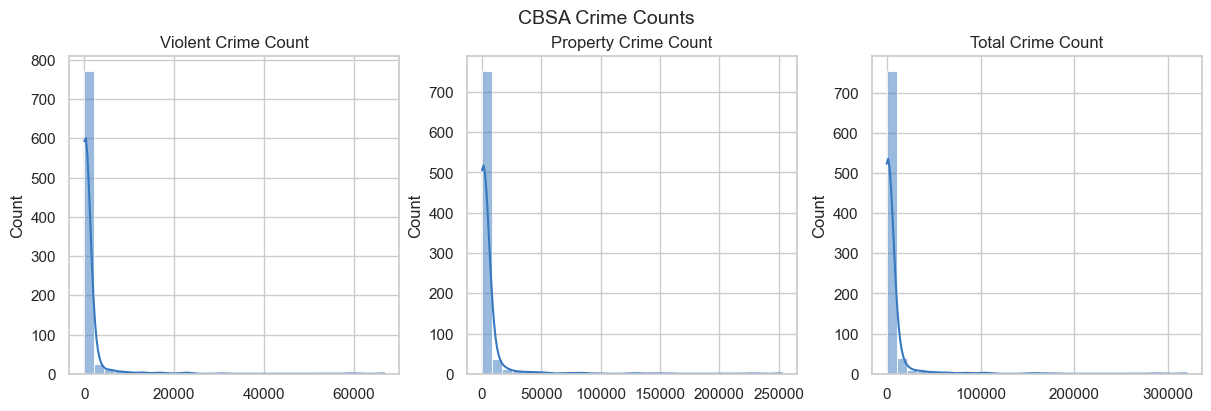

In [11]:
crime_features = ['violent_crime_count', 'property_crime_count',
       'total_crime_count'
]

# Drop rows where all selected features are missing
crime_plot_df = crime_df[crime_features].dropna(how="all")

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, len(crime_features), figsize=(4 * len(crime_features), 4), constrained_layout=True)

if len(crime_features) == 1:
    axes = [axes]

for ax, col in zip(axes, crime_features):
    # Use log scale for very right-skewed distributions where possible
    data = crime_plot_df[col].dropna()
    if not data.empty:
        sns.histplot(data, bins=30, kde=True, ax=ax, color="#3778bf")
        ax.set_title(col.replace("_", " ").title())
        ax.set_xlabel("")

plt.suptitle("CBSA Crime Counts", fontsize=14)
plt.show()

Crime Data seems to be extremely skewed, we may want to transform this data by population, will adddress in final_dataset_loader.py

## [Weather Data](https://www.ncei.noaa.gov/access/search/?types=dataset)

In [12]:
weather_df = pd.read_csv('data/processed/Weather_Data.csv')
weather_df = weather_df.drop(['cbsa_name', 'centroid_lat', 'centroid_lon','cbsa_type', 'station_id', 'station_name', 'n_months_available', 'has_complete_year'], axis=1)
weather_df.head()

,cbsa_code,station_distance_km,avg_annual_temp,jan_avg_temp,jul_avg_temp,annual_precipitation,annual_snowfall,temp_seasonality,snow_binary
0,10180,5.742564,66.364110,46.1,84.9,26.05,3.6,38.8,1
1,10300,3.165808,49.726301,25.0,73.0,31.97,NaN,48.0,0
2,10380,6.411777,78.706575,75.6,80.7,79.66,NaN,5.1,0
3,10420,5.788043,49.607945,25.8,72.9,45.74,49.5,47.1,1
4,10540,13.615525,52.509863,40.5,66.8,53.62,NaN,26.3,0


In [13]:
weather_df.columns

Index(['cbsa_code', 'station_distance_km', 'avg_annual_temp', 'jan_avg_temp',
       'jul_avg_temp', 'annual_precipitation', 'annual_snowfall',
       'temp_seasonality', 'snow_binary'],
      dtype='str')

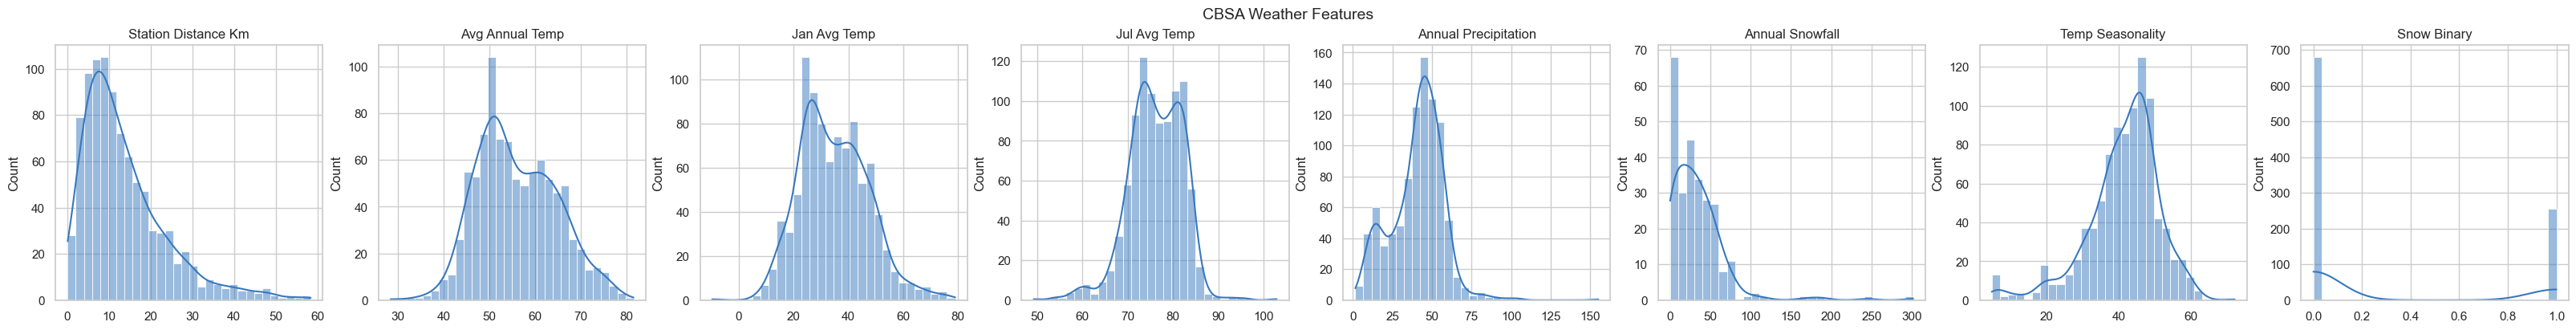

In [14]:
weather_features = [
    "station_distance_km",
    "avg_annual_temp",
    "jan_avg_temp",
    "jul_avg_temp",
    "annual_precipitation",
    "annual_snowfall",
    "temp_seasonality",
    "snow_binary"
]

# Drop rows where all selected features are missing
weather_plot_df = weather_df[weather_features].dropna(how="all")

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, len(weather_features), figsize=(4 * len(weather_features), 4), constrained_layout=True)

if len(weather_features) == 1:
    axes = [axes]

for ax, col in zip(axes, weather_features):
    # Use log scale for very right-skewed distributions where possible
    data = weather_plot_df[col].dropna()
    if not data.empty:
        sns.histplot(data, bins=30, kde=True, ax=ax, color="#3778bf")
        ax.set_title(col.replace("_", " ").title())
        ax.set_xlabel("")

plt.suptitle("CBSA Weather Features", fontsize=14)
plt.show()

## [Places Data](https://data.cdc.gov/500-Cities-Places/PLACES-County-Data-GIS-Friendly-Format-2025-releas/i46a-9kgh/about_data)

In [15]:
places_df = pd.read_csv('data/processed/Places_Data.csv')
places_df.head()

,cbsa_code,cbsa_title,n_tracts,total_population_weight,obesity_share,physical_inactivity_share,depression_share,current_asthma_share,diabetes_share,stroke_share,coronary_heart_disease_share,arthritis_share,any_disability_share,current_smoking_share,binge_drinking_share
0,10100,"Aberdeen, SD",10,32315,34.901711,24.237020,20.380343,9.771295,11.137416,3.335928,6.596871,27.861677,30.505292,14.208278,17.126502
1,10140,"Aberdeen, WA",20,60530,37.025057,23.624243,27.132959,11.732004,13.412424,4.144563,7.906169,31.228663,35.458485,15.352285,15.579366
2,10180,"Abilene, TX",49,135448,35.394659,27.259091,23.362871,10.152727,12.225254,3.430680,6.325994,24.326645,32.558226,14.047483,17.682745
3,10220,"Ada, OK",11,28970,39.905537,29.864919,25.613345,12.101740,12.410335,3.843983,7.454902,28.357352,37.775495,16.767846,14.412803
4,10300,"Adrian, MI",25,78518,40.794930,26.490344,27.941694,11.535894,12.395936,3.773098,7.485598,29.764913,33.424492,15.840312,16.260148


In [16]:
places_df.columns

Index(['cbsa_code', 'cbsa_title', 'n_tracts', 'total_population_weight',
       'obesity_share', 'physical_inactivity_share', 'depression_share',
       'current_asthma_share', 'diabetes_share', 'stroke_share',
       'coronary_heart_disease_share', 'arthritis_share',
       'any_disability_share', 'current_smoking_share',
       'binge_drinking_share'],
      dtype='str')

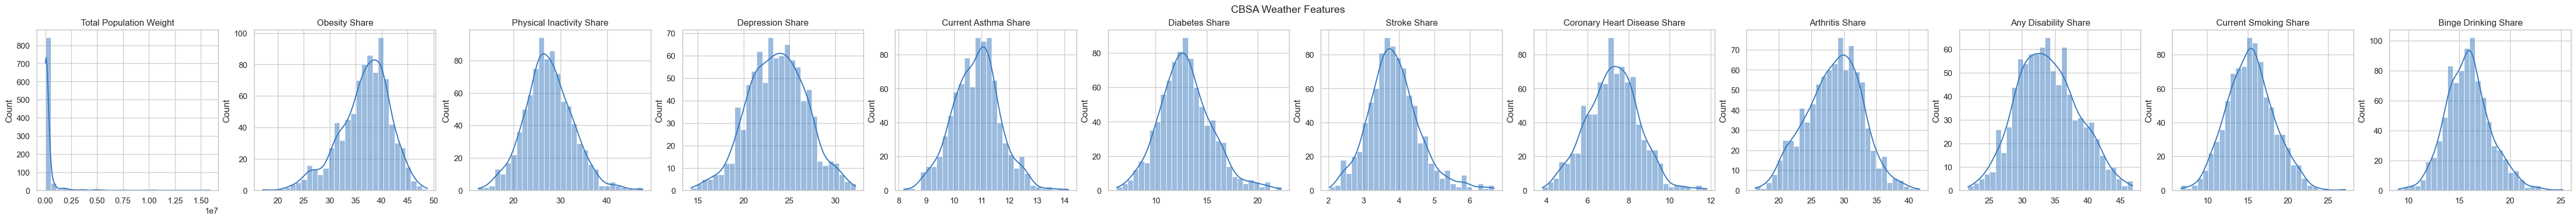

In [17]:
places_features = [ 'total_population_weight',
       'obesity_share', 'physical_inactivity_share', 'depression_share',
       'current_asthma_share', 'diabetes_share', 'stroke_share',
       'coronary_heart_disease_share', 'arthritis_share',
       'any_disability_share', 'current_smoking_share',
       'binge_drinking_share'
]

# Drop rows where all selected features are missing
places_plot_df = places_df[places_features].dropna(how="all")

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, len(places_features), figsize=(4 * len(places_features), 4), constrained_layout=True)

if len(places_features) == 1:
    axes = [axes]

for ax, col in zip(axes, places_features):
    # Use log scale for very right-skewed distributions where possible
    data = places_plot_df[col].dropna()
    if not data.empty:
        sns.histplot(data, bins=30, kde=True, ax=ax, color="#3778bf")
        ax.set_title(col.replace("_", " ").title())
        ax.set_xlabel("")

plt.suptitle("CBSA Weather Features", fontsize=14)
plt.show()

## Review NaN count

In [18]:
all_df = census_df.merge(crime_df, on='cbsa_code', how='left').merge(walk_df, on='cbsa_code', how='left').merge(weather_df, on='cbsa_code', how='left').merge(places_df,on='cbsa_code', how='left')
all_df.head()

,cbsa_code,cbsa_name,MedianHouseholdIncome_B19013,TotalPopulation_B01003,MedianAge_B01002,TotalPovertyUniverse_B17001,BelowPoverty_B17001,IndustryTotalEmployed_C24050,IndustryAgForestryMining_C24050,IndustryConstruction_C24050,...,physical_inactivity_share,depression_share,current_asthma_share,diabetes_share,stroke_share,coronary_heart_disease_share,arthritis_share,any_disability_share,current_smoking_share,binge_drinking_share
0,10100,"Aberdeen, SD Micro Area",70761,42112,38.2,40877,4246,22300,1636,1287,...,24.237020,20.380343,9.771295,11.137416,3.335928,6.596871,27.861677,30.505292,14.208278,17.126502
1,10140,"Aberdeen, WA Micro Area",63539,76397,44.7,73378,10358,29889,1738,1619,...,23.624243,27.132959,11.732004,13.412424,4.144563,7.906169,31.228663,35.458485,15.352285,15.579366
2,10180,"Abilene, TX Metro Area",66464,178244,34.4,166018,21841,79704,2095,5731,...,27.259091,23.362871,10.152727,12.225254,3.430680,6.325994,24.326645,32.558226,14.047483,17.682745
3,10220,"Ada, OK Micro Area",62564,38158,37.5,36961,4641,17552,564,1300,...,29.864919,25.613345,12.101740,12.410335,3.843983,7.454902,28.357352,37.775495,16.767846,14.412803
4,10300,"Adrian, MI Micro Area",67013,98823,42.2,93980,10915,43982,1299,2858,...,26.490344,27.941694,11.535894,12.395936,3.773098,7.485598,29.764913,33.424492,15.840312,16.260148


In [19]:
all_df.columns

Index(['cbsa_code', 'cbsa_name', 'MedianHouseholdIncome_B19013',
       'TotalPopulation_B01003', 'MedianAge_B01002',
       'TotalPovertyUniverse_B17001', 'BelowPoverty_B17001',
       'IndustryTotalEmployed_C24050', 'IndustryAgForestryMining_C24050',
       'IndustryConstruction_C24050',
       ...
       'physical_inactivity_share', 'depression_share', 'current_asthma_share',
       'diabetes_share', 'stroke_share', 'coronary_heart_disease_share',
       'arthritis_share', 'any_disability_share', 'current_smoking_share',
       'binge_drinking_share'],
      dtype='str', length=118)

In [20]:
all_df['annual_snowfall'] = all_df['annual_snowfall'].fillna(0)

<Axes: >

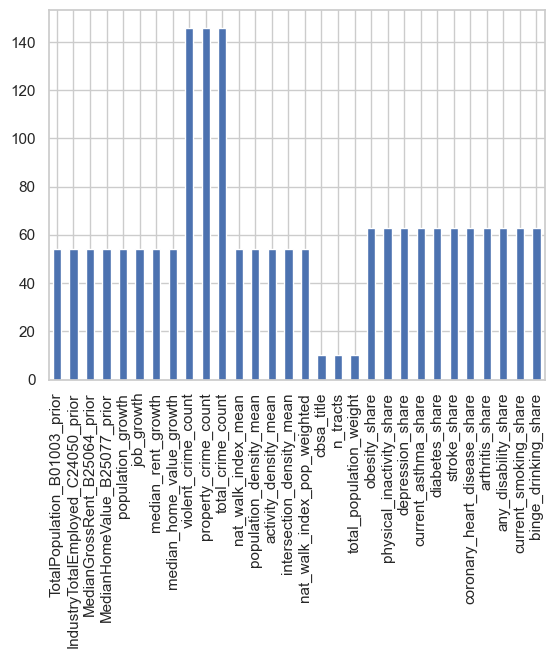

In [21]:
all_df.isna().sum().loc[lambda s: s > 0].plot(kind="bar")

In [22]:
# Basic inspection
print(all_df.shape)
all_df.head()

# Check data types
all_df.dtypes

# Check missing values
na_counts = all_df.isna().sum().sort_values(ascending=False)
na_percent = (all_df.isna().mean() * 100).sort_values(ascending=False)

pd.DataFrame({
    "NA_Count": na_counts,
    "NA_Percent": na_percent
}).head(20)

(935, 118)


,NA_Count,NA_Percent
total_crime_count,146,15.614973
violent_crime_count,146,15.614973
property_crime_count,146,15.614973
current_smoking_share,63,6.737968
any_disability_share,63,6.737968
physical_inactivity_share,63,6.737968
depression_share,63,6.737968
obesity_share,63,6.737968
current_asthma_share,63,6.737968
diabetes_share,63,6.737968


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=eeaff733-bf4c-45b4-9fa5-aa4724c7f5cd' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>